## 1. Setup and imports


In [1]:
# Notebook designed to run from a subdirectory
%matplotlib inline
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append("../")

import aif360.algorithms.preprocessing
from aif360.datasets import BinaryLabelDataset, StructuredDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.algorithms.preprocessing.reweighing import Reweighing
from aif360.algorithms.inprocessing.adversarial_debiasing import AdversarialDebiasing
from aif360.metrics.utils import compute_boolean_conditioning_vector
from aif360.algorithms.postprocessing.calibrated_eq_odds_postprocessing import CalibratedEqOddsPostprocessing


# for definition of original models
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report


import tensorflow as tf
from IPython.display import Markdown, display
import warnings

2026-06-17 16:42:11.849270: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-17 16:42:12.884551: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-17 16:42:15.412813: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/len_lin/Documents/ADNI/.venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
pip install 'aif360[inFairness]'


## 2. Fairness metrics


In [2]:
# Wraps aif360 ClassificationMetric into a clean OrderedDict
from collections import OrderedDict
from aif360.metrics import ClassificationMetric

def compute_metrics(dataset_true, dataset_pred, 
                    unprivileged_groups, privileged_groups,
                    disp = True):
    """ Compute the key metrics """
    classified_metric_pred = ClassificationMetric(dataset_true,
                                                 dataset_pred, 
                                                 unprivileged_groups=unprivileged_groups,
                                                 privileged_groups=privileged_groups)
    metrics = OrderedDict()
    metrics["Balanced accuracy"] = 0.5*(classified_metric_pred.true_positive_rate()+
                                             classified_metric_pred.true_negative_rate())
    
    metrics["Average odds difference"] = classified_metric_pred.average_odds_difference()
    metrics["Disparate impact"] = classified_metric_pred.disparate_impact()
    metrics["Equal opportunity difference"] = classified_metric_pred.equal_opportunity_difference()
    metrics["Mean Difference"] = classified_metric_pred.mean_difference()
    metrics["Statistical parity difference"] = classified_metric_pred.statistical_parity_difference()
    metrics["Theil index"] = classified_metric_pred.theil_index()
    
    if disp:
        for k in metrics:
            print("%s = %.4f" % (k, metrics[k]))
    
    return metrics

## 3. Data preparation


In [3]:
# 757 subjects x 147 columns; Sex: 0=male, 1=female; DIAGNOSIS: 0=MCI, 1=AD
df = pd.read_csv('data_4mod_MCIvsAD.csv')
print(df.shape)
df.head()

(757, 147)


,PTID,DIAGNOSIS,Sex,age,DXNODEP,DXMCI,DXMPTR1,DXMPTR2,DXMPTR3,DXMPTR4,...,RIGHT_BA36_NS,RIGHT_PHC_VOL,RIGHT_PHC_NS,RIGHT_SULCUS_VOL,RIGHT_SULCUS_NS,RIGHT_CA_VOL,RIGHT_CA_NS,RIGHT_HIPP_VOL,RIGHT_HIPP_NS,ICV
0,002_S_1155,0,0,57.9,0,0,1,1,1,1,...,12.0,0.040663,7.0,0.017779,18.0,0.094855,20.0,0.153476,20.0,1536260.810
1,002_S_4229,0,0,66.4,0,0,1,0,1,1,...,14.0,0.043713,8.0,0.015407,20.0,0.087257,21.0,0.132635,21.0,1447939.000
2,002_S_4473,0,0,74.8,0,0,1,1,1,1,...,13.0,0.053020,8.0,0.026710,20.0,0.077603,21.0,0.137151,21.0,1678392.749
3,002_S_4654,0,1,75.5,0,0,1,1,1,1,...,11.0,0.045150,8.0,0.027749,19.0,0.067913,19.0,0.119390,19.0,1548503.921
4,002_S_4799,0,0,81.3,0,0,1,0,1,1,...,13.0,0.043899,7.0,0.025049,18.0,0.086488,19.0,0.133770,19.0,1560673.616


In [4]:
# Check joint distribution of diagnosis and sex
print(df.value_counts(subset=['DIAGNOSIS', 'Sex'], sort=False))

DIAGNOSIS  Sex
0          0      331
           1      269
1          0       89
           1       68
Name: count, dtype: int64


In [5]:
print(df['Sex'].value_counts())
df['Sex'].value_counts(normalize=True)
print(df['DIAGNOSIS'].value_counts())

Sex
0    420
1    337
Name: count, dtype: int64
DIAGNOSIS
0    600
1    157
Name: count, dtype: int64


In [6]:
# Save PTIDs for later identification
df_PTID=df[['PTID']]
# print(df_PTID.shape)
# df_PTID.head()

In [7]:
# Drop metadata, diagnosis flags, and DXMPTR* proxy columns (18 total)
df = df.drop(['PTID','CDRSB', 'PTHAND', 'PTCOGBEG', 'DXDSEV','DXMDUE', 'DXMCI', 'DXAD', 'DXAPP', 'DXDDUE', 'PTADDX', 'ICV'], axis=1) 
df = df.drop(['DXMPTR1', 'DXMPTR2', 'DXMPTR3', 'DXMPTR4', 'DXMPTR5', 'DXMPTR6'], axis=1)
print(df.shape)
df.head()

(757, 129)


,DIAGNOSIS,Sex,age,DXNODEP,DXPARK,DXPDES,DXPCOG,DXPATYP,DXDEP,DXOTHDEM,...,RIGHT_BA36_VOL,RIGHT_BA36_NS,RIGHT_PHC_VOL,RIGHT_PHC_NS,RIGHT_SULCUS_VOL,RIGHT_SULCUS_NS,RIGHT_CA_VOL,RIGHT_CA_NS,RIGHT_HIPP_VOL,RIGHT_HIPP_NS
0,0,0,57.9,0,0,0,0,0,0,0,...,0.099781,12.0,0.040663,7.0,0.017779,18.0,0.094855,20.0,0.153476,20.0
1,0,0,66.4,0,0,0,0,0,0,0,...,0.122244,14.0,0.043713,8.0,0.015407,20.0,0.087257,21.0,0.132635,21.0
2,0,0,74.8,0,0,0,0,0,0,0,...,0.093440,13.0,0.053020,8.0,0.026710,20.0,0.077603,21.0,0.137151,21.0
3,0,1,75.5,0,0,0,0,0,0,0,...,0.059399,11.0,0.045150,8.0,0.027749,19.0,0.067913,19.0,0.119390,19.0
4,0,0,81.3,0,0,0,0,0,0,0,...,0.127571,13.0,0.043899,7.0,0.025049,18.0,0.086488,19.0,0.133770,19.0


In [8]:
# Sex=0 (male)=privileged, Sex=1 (female)=unprivileged; favorable label = AD (1)
# Binarize Training data
label_name = ['DIAGNOSIS']
protected_attribute_names = ['Sex']
    
dataset_Binary = BinaryLabelDataset(
    df=df,
    label_names=label_name,
    protected_attribute_names=protected_attribute_names,
    favorable_label=1,
    unfavorable_label=0)

unique_labels = dataset_Binary.labels.ravel() 

if len(np.unique(unique_labels)) != 2:
    raise ValueError("Dataset does not contain binary labels")
    
for attr in protected_attribute_names:
    unique_attrs = dataset_Binary.protected_attributes[:, dataset_Binary.protected_attribute_names.index(attr)]
    if len(np.unique(unique_attrs)) != 2:
        raise ValueError(f"Protected attribute '{attr}' is not binary")

In [9]:
# Get the dataset and split into train and test
# 66/34 split -> ~499 train / ~258 validation
dataset_orig_train, dataset_orig_valid = dataset_Binary.split([0.66])

privileged_groups = [{'Sex': 0}]
unprivileged_groups = [{'Sex': 1}]

In [10]:
metric_orig_train = BinaryLabelDatasetMetric(dataset_orig_train, 
                                             unprivileged_groups=unprivileged_groups,
                                             privileged_groups=privileged_groups)

display(Markdown("#### Original training dataset"))
print("disparate impact = %f" % metric_orig_train.disparate_impact())
print("Statistical parity difference = %f" % metric_orig_train.statistical_parity_difference())

#### Original training dataset

disparate impact = 0.823206
Statistical parity difference = -0.036119


In [11]:
metric_orig_valid = BinaryLabelDatasetMetric(dataset_orig_valid, 
                                             unprivileged_groups=unprivileged_groups,
                                             privileged_groups=privileged_groups)

display(Markdown("#### Original validation dataset"))
print("disparate impact = %f" % metric_orig_valid.disparate_impact())
print("Statistical parity difference = %f" % metric_orig_valid.statistical_parity_difference())

#### Original validation dataset

disparate impact = 1.167468
Statistical parity difference = 0.038007


In [12]:
X_train = dataset_orig_train.features
y_train = dataset_orig_train.labels.ravel()

# OS ratio in the training sample
# -------------------------------------
# uniqueytrain, countsytrain = np.unique(y_train, return_counts=True)
# display(Markdown("#### no of patients / controls in the Training dataset"))
# print(countsytrain)

In [13]:
# SMOTE resampling to balance MCI/AD (random_state=2 matches original analysis)
smote = SMOTE(random_state=2)
X_train_sampled, y_train_sampled = smote.fit_resample(X_train, y_train)

scale_orig = StandardScaler()
X_train = scale_orig.fit_transform(X_train_sampled)
y_train = y_train_sampled
X_valid = scale_orig.transform(dataset_orig_valid.features)


In [14]:
display(Markdown("#### Training Dataset shape after resampling"))
print(X_train.shape)

uniqueytrain, countsytrain = np.unique(y_train, return_counts=True)
display(Markdown("#### no of MCI / AD"))
print(countsytrain)

#### Training Dataset shape after resampling

(810, 128)


#### no of MCI / AD

[405 405]


## 4. Original model: training


SVC with poly kernel (C=0.1, gamma=0.1). Parameters were explored via GridSearchCV (C, kernel, gamma combinations); the chosen values are hardcoded for reproducibility.


In [15]:
# SVC with poly kernel; params pre-selected via GridSearch
model = SVC(C=0.1, gamma=0.1, kernel='poly', random_state=42, probability=True)
model.fit(X_train, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [16]:
# Predict training labels into aif360 dataset format
y_train_pred = model.predict(X_train)

pos_ind = np.where(model.classes_ == dataset_orig_train.favorable_label)[0][0]
dataset_orig_train_pred = dataset_orig_train.copy()
dataset_orig_train_pred.labels = y_train_pred

In [17]:
# Get probability scores on validation set for threshold tuning
## validation set
dataset_orig_valid_pred = dataset_orig_valid.copy(deepcopy=True)
X_test = scale_orig.transform(dataset_orig_valid_pred.features)
y_test = dataset_orig_valid_pred.labels
dataset_orig_valid_pred.scores = model.predict_proba(X_test)[:,pos_ind]

## 5. Original model: evaluation and threshold tuning


In [18]:
# Scan 100 thresholds (0.01-0.99) to maximize balanced accuracy
# Predictions from the original test set at the optimal classification threshold
# Find the optimal classification threshold from the test set
import numpy as np
np.seterr(divide='ignore', invalid='ignore')

num_thresh = 100
ba_arr = np.zeros(num_thresh)
class_thresh_arr = np.linspace(0.01, 0.99, num_thresh)
for idx, class_thresh in enumerate(class_thresh_arr):
    
    fav_inds = dataset_orig_valid_pred.scores > class_thresh
    dataset_orig_valid_pred.labels[fav_inds] = dataset_orig_valid_pred.favorable_label
    dataset_orig_valid_pred.labels[~fav_inds] = dataset_orig_valid_pred.unfavorable_label
    
    classified_metric_valid = ClassificationMetric(dataset_orig_valid,
                                             dataset_orig_valid_pred, 
                                             unprivileged_groups=unprivileged_groups,
                                             privileged_groups=privileged_groups)
    
    ba_arr[idx] = 0.5*(classified_metric_valid.true_positive_rate()\
                       +classified_metric_valid.true_negative_rate())

best_ind = np.where(ba_arr == np.max(ba_arr))[0][0]
best_class_thresh = class_thresh_arr[best_ind]
dataset_orig_valid_pred.unfavorable_label

display(Markdown("#### Predictions from original testing data"))
bal_acc_arr_orig = []
avg_odds_diff_arr_orig = []
disp_imp_arr_orig = []
equal_opp_diff_arr_orig = [] #equal_opportunity_difference
mean_diff_arr_orig = []
stat_par_arr_orig = []
theil_ind_arr_orig = []


print("Classification threshold used = %.4f" % best_class_thresh)
for thresh in tqdm(class_thresh_arr):
    
    if thresh == best_class_thresh:
        disp = True
    else:
        disp = False
    
    fav_inds = dataset_orig_valid_pred.scores > thresh
    dataset_orig_valid_pred.labels[fav_inds] = dataset_orig_valid_pred.favorable_label
    dataset_orig_valid_pred.labels[~fav_inds] = dataset_orig_valid_pred.unfavorable_label
    
    metric_valid_bef = compute_metrics(dataset_orig_valid, dataset_orig_valid_pred, 
                                      unprivileged_groups, privileged_groups,
                                      disp = disp)

    bal_acc_arr_orig.append(metric_valid_bef["Balanced accuracy"])
    avg_odds_diff_arr_orig.append(metric_valid_bef["Average odds difference"])
    disp_imp_arr_orig.append(metric_valid_bef["Disparate impact"])
    equal_opp_diff_arr_orig.append(metric_valid_bef["Equal opportunity difference"])
    mean_diff_arr_orig.append(metric_valid_bef["Mean Difference"])
    stat_par_arr_orig.append(metric_valid_bef["Statistical parity difference"])
    theil_ind_arr_orig.append(metric_valid_bef["Theil index"])

#### Predictions from original testing data

Classification threshold used = 0.0298


100%|██████████| 100/100 [00:00<00:00, 971.97it/s]

Balanced accuracy = 0.8554
Average odds difference = -0.0791
Disparate impact = 0.9350
Equal opportunity difference = -0.1290
Mean Difference = -0.0267
Statistical parity difference = -0.0267
Theil index = 0.0606


## 6. Debiasing with Disparate Impact Remover


In [ ]:
# DisparateImpactRemover pre-processing (repair_level=1 = full repair)
DIR = aif360.algorithms.preprocessing.DisparateImpactRemover(
       repair_level=1,  
       sensitive_attribute='Sex')

dataset_transf_train = DIR.fit_transform(dataset_orig_train)  

In [21]:
metric_transf_train = BinaryLabelDatasetMetric(dataset_transf_train, 
                                         unprivileged_groups=unprivileged_groups,
                                         privileged_groups=privileged_groups)

display(Markdown("#### Transformed training dataset "))
print("mean difference = %f" % metric_transf_train.mean_difference())
print("disparate impact = %f" % metric_transf_train.disparate_impact())
print("Statistical parity difference = %f" % metric_transf_train.statistical_parity_difference())

#### Transformed training dataset 

mean difference = -0.036119
disparate impact = 0.823206
Statistical parity difference = -0.036119


## 7. Debiased model: training


In [22]:
# SMOTE on debiased training data
smote_transf = SMOTE(random_state=2)
X_train_transf = dataset_transf_train.features
y_train_transf = dataset_transf_train.labels.ravel()
X_train_transf_sampled,y_train_transf_sampled = smote_transf.fit_resample(X_train_transf, y_train_transf)

scale_transf = StandardScaler()
X_train_transf = scale_transf.fit_transform(X_train_transf_sampled)
y_train_transf = y_train_transf_sampled

In [23]:
# Train SVC on the debiased (DisparateImpactRemover) features
# transfer SVM model
model_transf = SVC(C=0.1, gamma=0.1, kernel='poly',  random_state=42, probability=True) 
model_transf.fit(X_train_transf, y_train_transf)

pos_ind = np.where(model_transf.classes_ == dataset_transf_train.favorable_label)[0][0]
y_train_transf_pred = model_transf.predict(X_train_transf)

## 8. Debiased model: evaluation and threshold tuning


In [ ]:
dataset_transf_valid_pred = dataset_orig_valid.copy(deepcopy=True)
X_test_transf = scale_transf.fit_transform(dataset_transf_valid_pred.features)
y_test_transf = dataset_transf_valid_pred.labels
dataset_transf_valid_pred.scores = model_transf.predict_proba(X_test_transf)[:, pos_ind]

In [34]:
# Scan thresholds for debiased model predictions
# Predictions from the transformed test set at the optimal classification threshold
num_thresh = 100
ba_arr = np.zeros(num_thresh)
class_thresh_arr_transf = np.linspace(0.01, 0.99, num_thresh)
for idx, class_thresh in enumerate(class_thresh_arr_transf):
    
    fav_inds = dataset_transf_valid_pred.scores > class_thresh
    dataset_transf_valid_pred.labels[fav_inds] = dataset_transf_valid_pred.favorable_label
    dataset_transf_valid_pred.labels[~fav_inds] = dataset_transf_valid_pred.unfavorable_label
    
    classified_metric_valid_transf = ClassificationMetric(dataset_orig_valid,
                                             dataset_transf_valid_pred, 
                                             unprivileged_groups=unprivileged_groups,
                                             privileged_groups=privileged_groups)
    
    ba_arr[idx] = 0.5*(classified_metric_valid_transf.true_positive_rate()\
                       +classified_metric_valid_transf.true_negative_rate())

best_ind = np.where(ba_arr == np.max(ba_arr))[0][0]
best_class_thresh = class_thresh_arr_transf[best_ind]

display(Markdown("#### Predictions from transformed testing data"))
bal_acc_arr_transf = []
avg_odds_diff_arr_transf = []
disp_imp_arr_transf = []
equal_opp_diff_arr_transf = [] #equal_opportunity_difference
mean_diff_arr_transf = []
stat_par_arr_transf = []
theil_ind_arr_transf = []

print("Classification threshold used = %.4f" % best_class_thresh)
for thresh in tqdm(class_thresh_arr_transf):
    
    if thresh == best_class_thresh:
        disp = True
    else:
        disp = False
    
    fav_inds = dataset_transf_valid_pred.scores > thresh
    dataset_transf_valid_pred.labels[fav_inds] = dataset_transf_valid_pred.favorable_label
    dataset_transf_valid_pred.labels[~fav_inds] = dataset_transf_valid_pred.unfavorable_label
    
    metric_valid_aft = compute_metrics(dataset_orig_valid, dataset_transf_valid_pred, 
                                      unprivileged_groups, privileged_groups,
                                      disp = disp)

    bal_acc_arr_transf.append(metric_valid_aft["Balanced accuracy"])
    avg_odds_diff_arr_transf.append(metric_valid_aft["Average odds difference"])
    disp_imp_arr_transf.append(metric_valid_aft["Disparate impact"])
    equal_opp_diff_arr_transf.append(metric_valid_aft["Equal opportunity difference"])
    mean_diff_arr_transf.append(metric_valid_aft["Mean Difference"])
    stat_par_arr_transf.append(metric_valid_aft["Statistical parity difference"])
    theil_ind_arr_transf.append(metric_valid_aft["Theil index"])

#### Predictions from transformed testing data

Classification threshold used = 0.4852


100%|██████████| 100/100 [00:00<00:00, 616.59it/s]

Balanced accuracy = 0.8976
Average odds difference = -0.0553
Disparate impact = 1.0591
Equal opportunity difference = -0.1321
Mean Difference = 0.0138
Statistical parity difference = 0.0138
Theil index = 0.0524


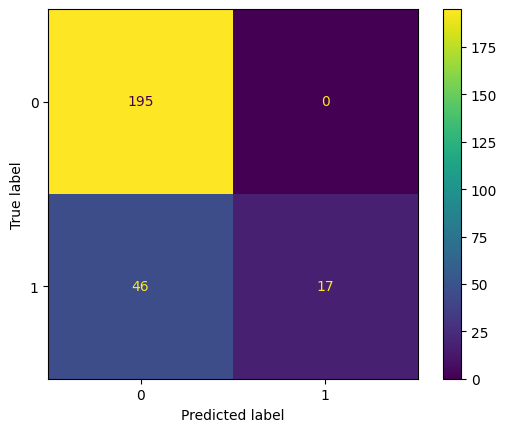

In [35]:
y_valid = dataset_orig_valid.labels
# y_pred = dataset_orig_valid_pred.labels

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
%matplotlib inline
cm_orig = confusion_matrix(y_valid, y_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_orig)
disp.plot()
plt.show()

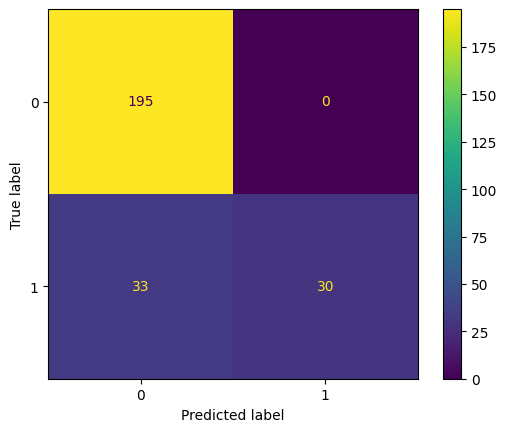

In [ ]:
cm_transf = confusion_matrix(y_valid, y_test_transf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_transf)
disp.plot()
plt.show()

## 9. Identification of 'corrected' patients


In [ ]:
# Extract PTIDs of validation set for result tracking
# # identify PTIDs of test cases
test_PTIDs = df_PTID[499:757] 
# print(test_PTIDs[:5])
# print (dataset_orig_valid.instance_names[:5])
test_PTIDs.reset_index(inplace=True)
test_PTIDs['index']
test_PTIDs = test_PTIDs.drop(['index'], axis=1) 
test_PTIDs

,PTID
0,116_S_4167
1,116_S_4175
2,116_S_4195
3,116_S_4199
4,116_S_4625
...,...
253,941_S_6803
254,941_S_6854
255,941_S_6962
256,941_S_7041


In [38]:
# Build comparison dataframe: true vs original vs debiased predictions
protected_attributes = dataset_transf_valid_pred.protected_attributes
protected_attributes.ravel()

df_ind = pd.DataFrame({
    "y_true": dataset_orig_valid.labels.ravel(),
    "pred_orig": dataset_orig_valid_pred.labels.ravel(),         
    "pred_transf": dataset_transf_valid_pred.labels.ravel(),                   
    "protected_attr": protected_attributes.ravel()
})
df_ind["Sex"] = df_ind["protected_attr"].map({0: "Male", 1: "Female"})
print(df_ind.shape)
df_ind.head()

(258, 5)


,y_true,pred_orig,pred_transf,protected_attr,Sex
0,0.0,0.0,0.0,1.0,Female
1,0.0,0.0,0.0,0.0,Male
2,1.0,1.0,1.0,0.0,Male
3,0.0,0.0,0.0,0.0,Male
4,1.0,0.0,1.0,0.0,Male


In [39]:
df_ind = pd.merge(test_PTIDs, df_ind, left_index=True, right_index=True)
print(df_ind.shape)
df_ind.tail()

(258, 6)


,PTID,y_true,pred_orig,pred_transf,protected_attr,Sex
253,941_S_6803,0.0,0.0,0.0,1.0,Female
254,941_S_6854,1.0,0.0,0.0,0.0,Male
255,941_S_6962,1.0,1.0,1.0,1.0,Female
256,941_S_7041,0.0,0.0,0.0,1.0,Female
257,941_S_7085,0.0,0.0,0.0,1.0,Female


In [40]:
# Identify cases misclassified by original but corrected by debiasing
improved_cases = df_ind[(df_ind['pred_orig'] != df_ind['y_true']) & (df_ind['pred_transf'] == df_ind['y_true'])]
# Print the result
print("Cases where the prediction was wrong before but correct after debiasing:")
print(len(improved_cases))
print(improved_cases[['PTID', 'y_true', 'pred_orig', 'pred_transf', 'Sex']])

Cases where the prediction was wrong before but correct after debiasing:
13
            PTID  y_true  pred_orig  pred_transf     Sex
4     116_S_4625     1.0        0.0          1.0    Male
33    126_S_6683     1.0        0.0          1.0    Male
46    127_S_6433     1.0        0.0          1.0    Male
48    127_S_6549     1.0        0.0          1.0    Male
112   135_S_5275     1.0        0.0          1.0  Female
152   141_S_0915     1.0        0.0          1.0  Female
153   141_S_1004     1.0        0.0          1.0    Male
178   168_S_6142     1.0        0.0          1.0  Female
191   168_S_6843     1.0        0.0          1.0  Female
203   301_S_6592     1.0        0.0          1.0    Male
220   341_S_6820     1.0        0.0          1.0    Male
233  941_S_10024     1.0        0.0          1.0    Male
237  941_S_10085     1.0        0.0          1.0  Female


## 10. Model interpretation with LIME


In [41]:
# LIME tabular explainer for interpretability
import lime
import lime.lime_tabular
from IPython.core.display import display, HTML
import warnings

/tmp/ipykernel_23021/3384812209.py:4: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [42]:
# Note: df.columns[1:150] is fragile — assumes consistent column ordering
X_train_XAI = pd.DataFrame(X_train)  
X_train_XAI.columns=df.columns[1:150]

X_test_XAI = pd.DataFrame(X_test) 
X_test_XAI.columns=df.columns[1:150]


# # Create a LIME explainer
class_names = [0, 1]
feature_names = list(X_train_XAI.columns)
explainer = lime.lime_tabular.LimeTabularExplainer(X_train_XAI.values, feature_names=feature_names, 
                                                        class_names=class_names, discretize_continuous=True)

In [ ]:
# List of test instance indices
instance_indices = [4, 33, 46, 48, 112, 152, 153, 178, 191, 203, 220, 233, 237]


# Store results
all_lime_values = []

for idx in instance_indices:
    # Explain instance with LIME
    exp = explainer.explain_instance(X_test[idx], model.predict_proba, num_features=len(feature_names))
    
    # Convert to dictionary
    lime_dict = dict(exp.as_list())
    
    # Ensure all features are present
    for f in feature_names:
        if f not in lime_dict:
            lime_dict[f] = 0.0  # fill missing features with 0 contribution
    
    # Add instance index
    lime_dict['instance_index'] = idx
    
    # Append to list
    all_lime_values.append(lime_dict)

# Convert to DataFrame
lime_df = pd.DataFrame(all_lime_values)

# # Ensure instance_index is first column
# cols = ['instance_index'] + feature_names
# lime_df = lime_df[cols]

# Display
# print(lime_df.shape)
# lime_df.head()

(13, 463)


In [50]:
df_lime_orig = lime_df.drop(['instance_index'], axis = 1)
df_lime_orig = df_lime_orig.dropna(axis=1)
df_lime_orig['gender'] = [1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0]  
print(df_lime_orig.shape)
# df_lime_orig.head()

(13, 158)


In [45]:
df_lime_orig_males = df_lime_orig[df_lime_orig['gender'] == 0] 
df_lime_orig_females = df_lime_orig[df_lime_orig['gender'] == 1] 

In [46]:
# Prepare transformed data for LIME comparison
X_train_transf = pd.DataFrame(X_train_transf) 
X_train_transf.columns=df.columns[1:150]

# X_test_transf = pd.DataFrame(X_test_transf) 
# X_test_transf.columns=df.columns[1:150]

# Create a LIME explainer
class_names = [0, 1]
feature_names_transf = list(X_train_transf.columns)
explainer_lime_transf = lime.lime_tabular.LimeTabularExplainer(X_train_transf.values, feature_names=feature_names_transf, 
                                                        class_names=class_names, discretize_continuous=True)

In [52]:
# List of test instance indices
instance_indices = [4, 33, 46, 48, 112, 152, 153, 178, 191, 203, 220, 233, 237]

# Store results
all_lime_values_transf= []

for idx in instance_indices:
    # Explain instance with LIME
    exp_transf = explainer_lime_transf.explain_instance(X_test_transf[idx], model_transf.predict_proba, num_features=len(feature_names))
    
    # Convert to dictionary
    lime_dict_transf = dict(exp_transf.as_list())
    
    # Ensure all features are present
    for f in feature_names:
        if f not in lime_dict_transf:
            lime_dict_transf[f] = 0.0  # fill missing features with 0 contribution
    
    # Add instance index
    lime_dict_transf['instance_index'] = idx
    
    # Append to list
    all_lime_values_transf.append(lime_dict_transf)

# Convert to DataFrame
lime_df_transf = pd.DataFrame(all_lime_values_transf)

# # Ensure instance_index is first column
# cols = ['instance_index'] + feature_names
# lime_df_transf = lime_df_transf[cols]

# Display
# print(lime_df_transf.shape)
# lime_df_transf.head()

In [48]:
df_lime_transf = lime_df_transf.drop(['instance_index'], axis = 1)
df_lime_transf = df_lime_transf.dropna(axis=1)
df_lime_transf['gender'] = [1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0]
df_lime_transf.shape

(13, 162)

In [49]:
df_lime_transf_males = df_lime_transf[df_lime_transf['gender'] == 0] 
df_lime_transf_females = df_lime_transf[df_lime_transf['gender'] == 1] 

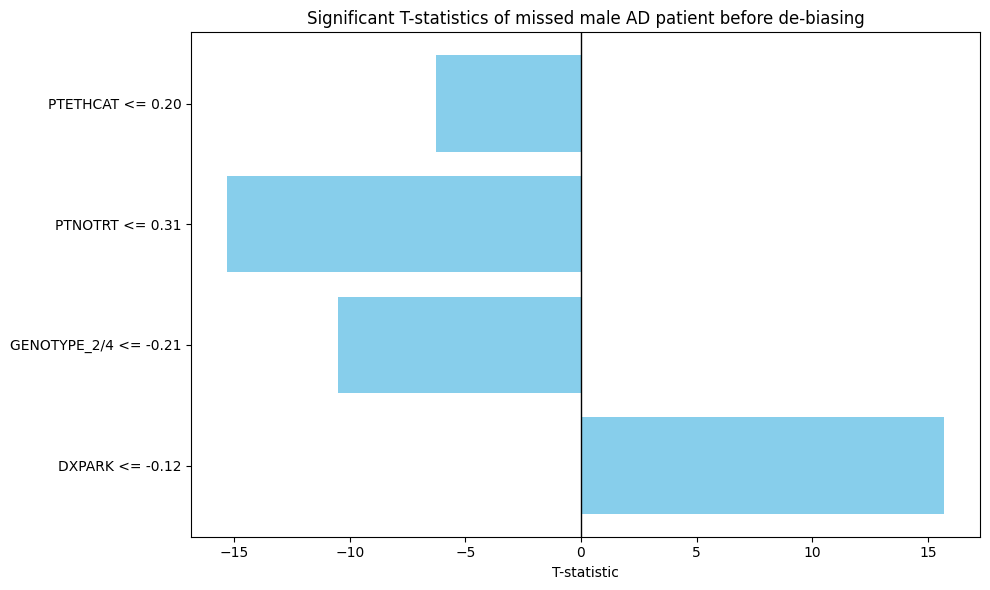

Significant Results (after Bonferroni correction, p-value < 0.05000):

Results for DXPARK <= -0.12:
T-statistic: 15.703
P-value: 0.000
Results for GENOTYPE_2/4 <= -0.21:
T-statistic: -10.518
P-value: 0.000
Results for PTNOTRT <= 0.31:
T-statistic: -15.301
P-value: 0.000
Results for PTETHCAT <= 0.20:
T-statistic: -6.278
P-value: 0.003


In [ ]:
### ========================================================
### test for statistical significance of feature importance 
### using sex-specific one-sample t-tests on lime values  
### before and after de-biasing
### p-values are corrected for multiple comparisons 
### ========================================================

from scipy import stats

# Hypothesized population mean (mu = 0)
population_mean = 0

# Create an empty dictionary to store results
results_orig_males = {}

# Number of tests (columns in the DataFrame)
num_tests = len(df_lime_orig_males.columns)

# Bonferroni-adjusted significance level (alpha = 0.05)
alpha_bonferroni_orig_males = 0.05 #/ num_tests

# Perform one-sample t-test across columns
for column in df_lime_orig_males.columns:
    sample_data_orig_males = df_lime_orig_males[column]
    t_statistic_orig_males, p_value_orig_males = stats.ttest_1samp(sample_data_orig_males, population_mean)
    
    # Check if the mean is significantly greater than 0 (one-tailed test)
    if t_statistic_orig_males > 0:
        p_value_orig_males /= 2  # one-tailed test for 'greater than 0'
    
    # Store results
    results_orig_males[column] = {
        'T-statistic': t_statistic_orig_males,
        'P-value': p_value_orig_males,
        'Reject Null Hypothesis': p_value_orig_males < alpha_bonferroni_orig_males
    }

# Filter out only significant columns (those where the null hypothesis is rejected)
significant_results_orig_males = {column: result for column, result in results_orig_males.items() if result['P-value'] < alpha_bonferroni_orig_males}

# ---- Bar Plot for Significant Features (T-statistics and P-values) ----

if significant_results_orig_males:
    # Set up the figure for the subplot
    plt.figure(figsize=(10, 6))

    # T-statistics plot (Horizontal Bar Plot)
    plt.barh(list(significant_results_orig_males.keys()), [result['T-statistic'] for result in significant_results_orig_males.values()], color='skyblue')
    plt.axvline(0, color='black', linewidth=1)  # Line at T = 0 for comparison
    plt.title('Significant T-statistics of missed male AD patient before de-biasing')
    plt.xlabel('T-statistic')

    # Adjust layout for better visualization
    plt.tight_layout()

    # Show the plot
    plt.show()

    # Print significant results
    print(f"Significant Results (after Bonferroni correction, p-value < {alpha_bonferroni_orig_males:.5f}):\n")
    for column, result in significant_results_orig_males.items():
        print(f"Results for {column}:")
        print(f"T-statistic: {result['T-statistic']:.3f}")
        print(f"P-value: {result['P-value']:.3f}")
else:
    print("No significant results after Bonferroni correction.")

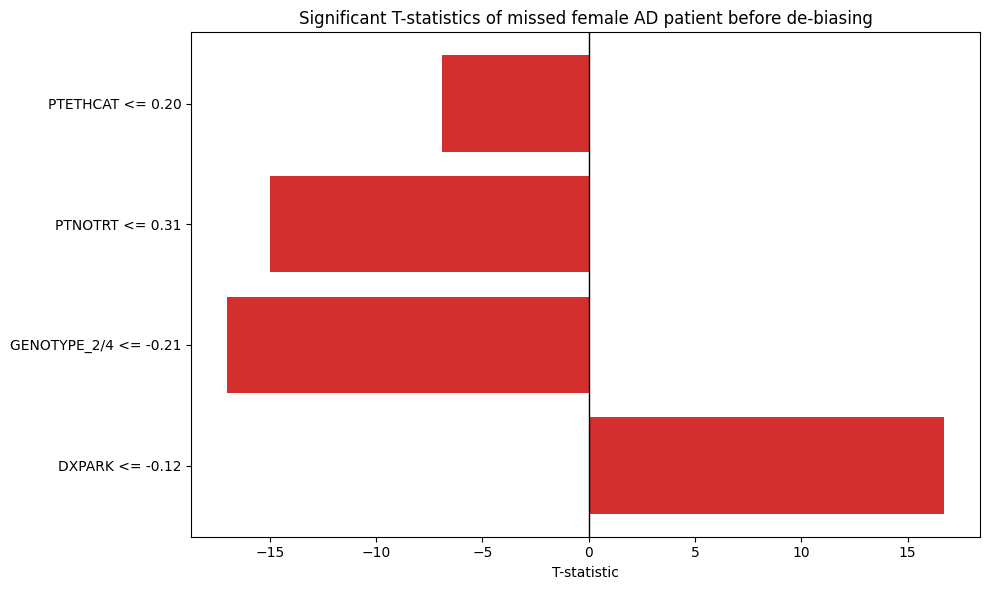

Significant Results (after Bonferroni correction, p-value < 0.00032):

Results for DXPARK <= -0.12:
T-statistic: 16.722
P-value: 0.000
Results for GENOTYPE_2/4 <= -0.21:
T-statistic: -17.004
P-value: 0.000
Results for PTNOTRT <= 0.31:
T-statistic: -14.990
P-value: 0.000
Results for PTETHCAT <= 0.20:
T-statistic: -6.906
P-value: 0.000
Results for gender:
T-statistic: inf
P-value: 0.000


In [55]:
# # One-sample t-test of LIME feature contributions vs mean=0, by sex
# from scipy import stats

# # Hypothesized population mean (mu = 0)
# population_mean = 0

# Create an empty dictionary to store results
results_orig_females = {}

# Number of tests (columns in the DataFrame)
num_tests = len(df_lime_orig_females.columns)

# Bonferroni-adjusted significance level (alpha = 0.05)
alpha_bonferroni_orig_females = 0.05 / num_tests

# Perform one-sample t-test across columns
for column in df_lime_orig_females.columns:
    sample_data_orig_females = df_lime_orig_females[column]
    t_statistic_orig_females, p_value_orig_females = stats.ttest_1samp(sample_data_orig_females, population_mean)
    
    # Check if the mean is significantly greater than 0 (one-tailed test)
    if t_statistic_orig_females > 0:
        p_value_orig_females /= 2  # one-tailed test for 'greater than 0'
    
    # Store results
    results_orig_females[column] = {
        'T-statistic': t_statistic_orig_females,
        'P-value': p_value_orig_females,
        'Reject Null Hypothesis': p_value_orig_females < alpha_bonferroni_orig_females
    }

# Filter out only significant columns (those where the null hypothesis is rejected)
significant_results_orig_females = {column: result for column, result in results_orig_females.items() if result['P-value'] < alpha_bonferroni_orig_females}

# ---- Bar Plot for Significant Features (T-statistics and P-values) ----

if significant_results_orig_females:
    # Set up the figure for the subplot
    plt.figure(figsize=(10, 6))

    # T-statistics plot (Horizontal Bar Plot)
    plt.barh(list(significant_results_orig_females.keys()), [result['T-statistic'] for result in significant_results_orig_females.values()], color='#D32F2F')
    plt.axvline(0, color='black', linewidth=1)  # Line at T = 0 for comparison
    plt.title('Significant T-statistics of missed female AD patient before de-biasing')
    plt.xlabel('T-statistic')

    # Adjust layout for better visualization
    plt.tight_layout()

    # Show the plot
    plt.show();

    # Print significant results
    print(f"Significant Results (after Bonferroni correction, p-value < {alpha_bonferroni_orig_females:.5f}):\n")
    for column, result in significant_results_orig_females.items():
        print(f"Results for {column}:")
        print(f"T-statistic: {result['T-statistic']:.3f}")
        print(f"P-value: {result['P-value']:.3f}")
else:
    print("No significant results after Bonferroni correction.")

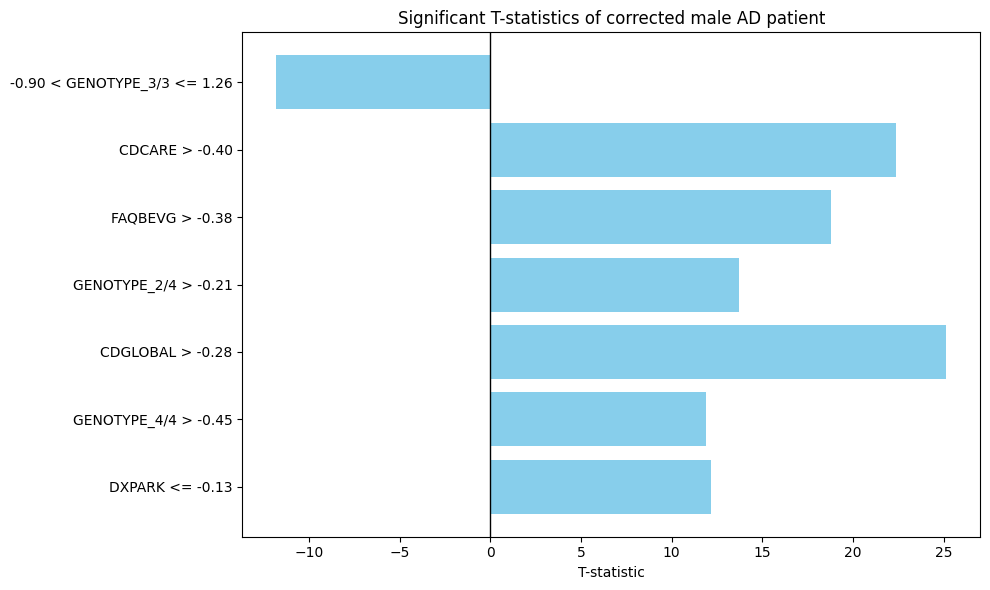

Significant Results (after Bonferroni correction, p-value < 0.00031):

Results for DXPARK <= -0.13:
T-statistic: 12.156
P-value: 0.000
Results for GENOTYPE_4/4 > -0.45:
T-statistic: 11.877
P-value: 0.000
Results for CDGLOBAL > -0.28:
T-statistic: 25.158
P-value: 0.000
Results for GENOTYPE_2/4 > -0.21:
T-statistic: 13.715
P-value: 0.000
Results for FAQBEVG > -0.38:
T-statistic: 18.799
P-value: 0.000
Results for CDCARE > -0.40:
T-statistic: 22.383
P-value: 0.000
Results for -0.90 < GENOTYPE_3/3 <= 1.26:
T-statistic: -11.828
P-value: 0.000


In [ ]:
# One-sample t-test of LIME feature contributions vs mean=0, by sex
# Hypothesized population mean (mu = 0)
# population_mean = 0

# Create an empty dictionary to store results
results_transf_males = {}

# Number of tests (columns in the DataFrame)
num_tests = len(df_lime_transf_males.columns)

# Bonferroni-adjusted significance level (alpha = 0.05)
alpha_bonferroni_transf_males = 0.05 / num_tests

# Perform one-sample t-test across columns
for column in df_lime_transf_males.columns:
    sample_data_transf_males = df_lime_transf_males[column]
    t_statistic_transf_males, p_value_transf_males = stats.ttest_1samp(sample_data_transf_males, population_mean)
    
    # Check if the mean is significantly greater than 0 (one-tailed test)
    if t_statistic_transf_males > 0:
        p_value_transf_males /= 2  # one-tailed test for 'greater than 0'
    
    # Store results
    results_transf_males[column] = {
        'T-statistic': t_statistic_transf_males,
        'P-value': p_value_transf_males,
        'Reject Null Hypothesis': p_value_transf_males < alpha_bonferroni_transf_males
    }

# Filter out only significant columns (those where the null hypothesis is rejected)
significant_results_transf_males = {column: result for column, result in results_transf_males.items() if result['P-value'] < alpha_bonferroni_transf_males}

# ---- Bar Plot for Significant Features (T-statistics and P-values) ----

if significant_results_transf_males:
    # Set up the figure for the subplot
    plt.figure(figsize=(10, 6))

    # T-statistics plot (Horizontal Bar Plot)
    plt.barh(list(significant_results_transf_males.keys()), [result['T-statistic'] for result in significant_results_transf_males.values()], color='skyblue')
    plt.axvline(0, color='black', linewidth=1)  # Line at T = 0 for comparison
    plt.title('Significant T-statistics of corrected male AD patient')
    plt.xlabel('T-statistic')

    # Adjust layout for better visualization
    plt.tight_layout()

    # Show the plot
    plt.show()

    # Print significant results
    print(f"Significant Results (after Bonferroni correction, p-value < {alpha_bonferroni_transf_males:.5f}):\n")
    for column, result in significant_results_transf_males.items():
        print(f"Results for {column}:")
        print(f"T-statistic: {result['T-statistic']:.3f}")
        print(f"P-value: {result['P-value']:.3f}")
else:
    print("No significant results after Bonferroni correction.")

In [ ]:
# One-sample t-test of LIME feature contributions vs mean=0, by sex
# # Hypothesized population mean (mu = 0)
# population_mean = 0

# Create an empty dictionary to store results
results_transf_females = {}

# Number of tests (columns in the DataFrame)
num_tests = len(df_lime_transf_females.columns)

# Bonferroni-adjusted significance level (alpha = 0.05)
alpha_bonferroni_transf_females = 0.05 / num_tests

# Perform one-sample t-test across columns
for column in df_lime_transf_females.columns:
    sample_data_transf_females = df_lime_transf_females[column]
    t_statistic_transf_females, p_value_transf_females = stats.ttest_1samp(sample_data_transf_females, population_mean)
    
    # Check if the mean is significantly greater than 0 (one-tailed test)
    if t_statistic_transf_females > 0:
        p_value_transf_females /= 2  # one-tailed test for 'greater than 0'
    
    # Store results
    results_transf_females[column] = {
        'T-statistic': t_statistic_transf_females,
        'P-value': p_value_transf_females,
        'Reject Null Hypothesis': p_value_transf_females < alpha_bonferroni_transf_females
    }

# Filter out only significant columns (those where the null hypothesis is rejected)
significant_results_transf_females = {column: result for column, result in results_transf_females.items() if result['P-value'] < alpha_bonferroni_transf_females}

# ---- Bar Plot for Significant Features (T-statistics and P-values) ----

if significant_results_transf_females:
    # Set up the figure for the subplot
    plt.figure(figsize=(10, 6))

    # T-statistics plot (Horizontal Bar Plot)
    plt.barh(list(significant_results_transf_females.keys()), [result['T-statistic'] for result in significant_results_transf_females.values()], color='#D32F2F')
    plt.axvline(0, color='black', linewidth=1)  # Line at T = 0 for comparison
    plt.title('Significant T-statistics of corrected female AD patient')
    plt.xlabel('T-statistic')

    # Adjust layout for better visualization
    plt.tight_layout()

    # Show the plot
    plt.show()

    # Print significant results
    print(f"Significant Results (after Bonferroni correction, p-value < {alpha_bonferroni_transf_females:.5f}):\n")
    for column, result in significant_results_transf_females.items():
        print(f"Results for {column}:")
        print(f"T-statistic: {result['T-statistic']:.3f}")
        print(f"P-value: {result['P-value']:.3f}")
else:
    print("No significant results after Bonferroni correction.")

---
## Appendix: additional mitigation algorithms


These methods were explored but not included in the main analysis. Code is preserved for reference.


### Adversarial Debiasing (in-processing, TF-based)


In [ ]:
#warnings.filterwarnings("ignore")
#tf.compat.v1.disable_eager_execution()  # Ensure TF2 compatibility
#sess = tf.compat.v1.Session()
#plain_model = aif360.algorithms.inprocessing.AdversarialDebiasing(
#    privileged_groups=privileged_groups,
#    unprivileged_groups=unprivileged_groups,
#    scope_name='original_model',
#    debias=False,
#    sess=sess,
#    num_epochs=50,
#    batch_size=128,
#    classifier_num_hidden_units=128
#)


#plain_model.fit(dataset_orig_train)
#dataset_nodebiasing_train = plain_model.predict(dataset_orig_train) 
#dataset_nodebiasing_valid = plain_model.predict(dataset_orig_valid) 

In [ ]:
#num_thresh = 100
#ba_arr = np.zeros(num_thresh)
#class_thresh_arr = np.linspace(0.01, 0.99, num_thresh)
#for idx, class_thresh in enumerate(class_thresh_arr):
#  
#    fav_inds = dataset_nodebiasing_valid.scores > class_thresh
#    dataset_nodebiasing_valid.labels[fav_inds] = dataset_nodebiasing_valid.favorable_label
#    dataset_nodebiasing_valid.labels[~fav_inds] = dataset_nodebiasing_valid.unfavorable_label
#    
#    classified_metric_valid = ClassificationMetric(dataset_orig_valid,
#                                             dataset_nodebiasing_valid, 
#                                             unprivileged_groups=unprivileged_groups,
#                                             privileged_groups=privileged_groups)
    
#    ba_arr[idx] = 0.5*(classified_metric_valid.true_positive_rate()\
#                       +classified_metric_valid.true_negative_rate())

#best_ind = np.where(ba_arr == np.max(ba_arr))[0][0]
#best_class_thresh = class_thresh_arr[best_ind]

#display(Markdown("#### Predictions from testing data before Adversarial Debiasing"))
#bal_acc_arr_orig = []
#disp_imp_arr_orig = []
## avg_odds_diff_arr_orig = []
#mean_diff_arr_orig = []

#print("Classification threshold used = %.4f" % best_class_thresh)
#for thresh in tqdm(class_thresh_arr):
#    
#    if thresh == best_class_thresh:
#        disp = True
#    else:
#        disp = False
   
#    fav_inds = dataset_nodebiasing_valid.scores > thresh
#    dataset_nodebiasing_valid.labels[fav_inds] = dataset_nodebiasing_valid.favorable_label
#    dataset_nodebiasing_valid.labels[~fav_inds] = dataset_nodebiasing_valid.unfavorable_label
    
#    metric_valid_bef = compute_metrics(dataset_orig_valid, dataset_nodebiasing_valid, 
#                                      unprivileged_groups, privileged_groups,
#                                      disp = disp)

#    bal_acc_arr_orig.append(metric_valid_bef["Balanced accuracy"])
#    # avg_odds_diff_arr_orig.append(metric_valid_bef["Average odds difference"])
#    disp_imp_arr_orig.append(metric_valid_bef["Disparate impact"])
#    mean_diff_arr_orig.append(metric_valid_bef["Mean Difference"])

In [ ]:
#warnings.filterwarnings("ignore")
## Learn parameters with debias set to True
#debiased_model = AdversarialDebiasing(privileged_groups = privileged_groups,
#                          unprivileged_groups = unprivileged_groups,
#                          scope_name='debiased_classifier',
#                          debias=True,
#                          sess=sess)
#debiased_model.fit(dataset_orig_train)
#dataset_debiasing_train = debiased_model.predict(dataset_orig_train)
#dataset_debiasing_valid = debiased_model.predict(dataset_orig_valid)

In [ ]:
#num_thresh = 100
#ba_arr = np.zeros(num_thresh)
#class_thresh_arr_debiased = np.linspace(0.01, 0.99, num_thresh)
#for idx, class_thresh in enumerate(class_thresh_arr_debiased):
    
#    fav_inds = dataset_debiasing_valid.scores > class_thresh
#    dataset_debiasing_valid.labels[fav_inds] = dataset_debiasing_valid.favorable_label
#    dataset_debiasing_valid.labels[~fav_inds] = dataset_debiasing_valid.unfavorable_label
    
#    classified_metric_valid = ClassificationMetric(dataset_orig_valid,
#                                             dataset_debiasing_valid, 
#                                             unprivileged_groups=unprivileged_groups,
#                                             privileged_groups=privileged_groups)
    
#    ba_arr[idx] = 0.5*(classified_metric_valid.true_positive_rate()\
#                       +classified_metric_valid.true_negative_rate())

#best_ind = np.where(ba_arr == np.max(ba_arr))[0][0]
#best_class_thresh_debiased = class_thresh_arr_debiased[best_ind]

#display(Markdown("#### Predictions from testing data after Adversarial Debiasing"))

#bal_acc_arr_debiased = []
#disp_imp_arr_debiased = []
#avg_odds_diff_arr_debiased = []
#mean_diff_arr_debiased = []

#print("Classification threshold used = %.4f" % best_class_thresh_debiased)
#for thresh in tqdm(class_thresh_arr_debiased):
    
#    if thresh == best_class_thresh_debiased:
#        disp = True
#    else:
#        disp = False
    
#    fav_inds = dataset_debiasing_valid.scores > thresh
#    dataset_debiasing_valid.labels[fav_inds] = dataset_debiasing_valid.favorable_label
#    dataset_debiasing_valid.labels[~fav_inds] = dataset_debiasing_valid.unfavorable_label
    
#    metric_valid_aft = compute_metrics(dataset_orig_valid, dataset_debiasing_valid, 
#                                      unprivileged_groups, privileged_groups,
#                                      disp = disp)

#    bal_acc_arr_debiased.append(metric_valid_aft["Balanced accuracy"])
#    # avg_odds_diff_arr_debiased.append(metric_valid_aft["Average odds difference"])
#    disp_imp_arr_debiased.append(metric_valid_aft["Disparate impact"])
#    mean_diff_arr_debiased.append(metric_valid_aft["Mean Difference"])

### Prejudice Remover (in-processing)


In [ ]:
#warnings.filterwarnings("ignore")
## # Learn parameters with debias set to True
#debiased_model_PR = aif360.algorithms.inprocessing.PrejudiceRemover()
#debiased_model_PR.fit(dataset_orig_train)

#dataset_debiasing_PR_train = debiased_model_PR.predict(dataset_orig_train)
#dataset_debiasing_PR_valid = debiased_model_PR.predict(dataset_orig_valid)

In [ ]:
#num_thresh = 100
#ba_arr = np.zeros(num_thresh)
#class_thresh_arr_PR = np.linspace(0.01, 0.99, num_thresh)
#for idx, class_thresh in enumerate(class_thresh_arr_PR):
    
#    fav_inds = dataset_debiasing_PR_valid.scores > class_thresh
#    dataset_debiasing_PR_valid.labels[fav_inds] = dataset_debiasing_PR_valid.favorable_label
#    dataset_debiasing_PR_valid.labels[~fav_inds] = dataset_debiasing_PR_valid.unfavorable_label
    
#    classified_metric_valid_PR = ClassificationMetric(dataset_orig_valid,
#                                             dataset_debiasing_PR_valid, 
#                                             unprivileged_groups=unprivileged_groups,
#                                             privileged_groups=privileged_groups)
    
#    ba_arr[idx] = 0.5*(classified_metric_valid_PR.true_positive_rate()\
#                       +classified_metric_valid_PR.true_negative_rate())

#best_ind = np.where(ba_arr == np.max(ba_arr))[0][0]
#best_class_thresh_PR = class_thresh_arr_PR[best_ind]
#display(Markdown("#### Predictions of testing data after Prejudice Remover"))

#bal_acc_arr_PR = []
#disp_imp_arr_PR = []
## avg_odds_diff_arr_PR = []
#mean_diff_arr_PR = []

#print("Classification threshold used = %.4f" % best_class_thresh_PR)
#for thresh in tqdm(class_thresh_arr_PR):
    
#    if thresh == best_class_thresh_PR:
#        disp = True
#    else:
#        disp = False
  
#    fav_inds = dataset_debiasing_PR_valid.scores > thresh
#    dataset_debiasing_PR_valid.labels[fav_inds] = dataset_debiasing_PR_valid.favorable_label
#    dataset_debiasing_PR_valid.labels[~fav_inds] = dataset_debiasing_PR_valid.unfavorable_label
    
#    metric_valid_aft = compute_metrics(dataset_orig_valid, dataset_debiasing_PR_valid, 
#                                      unprivileged_groups, privileged_groups,
#                                      disp = disp)

#    bal_acc_arr_PR.append(metric_valid_aft["Balanced accuracy"])
#    # avg_odds_diff_arr_PR.append(metric_test_aft["Average odds difference"])
#    disp_imp_arr_PR.append(metric_valid_aft["Disparate impact"])
#    mean_diff_arr_PR.append(metric_valid_aft["Mean Difference"])

### Calibrated Equal Odds Postprocessing 


In [ ]:
# # Calibrated Equal Odds Post-processing

# # cost constraint of fnr will optimize generalized false negative rates, that of
# # fpr will optimize generalized false positive rates, and weighted will optimize
# # a weighted combination of both
#cost_constraint = "fnr" # "fnr", "fpr", "weighted"
# #random seed for calibrated equal odds prediction
#randseed = 12345679 

#cm_pred_valid = ClassificationMetric(dataset_orig_valid, dataset_orig_valid_pred,
#                             unprivileged_groups=unprivileged_groups,
#                             privileged_groups=privileged_groups)
#display(Markdown("#### Original-Predicted validation dataset"))
#print("Difference in GFPR between unprivileged and privileged groups")
#print(cm_pred_valid.difference(cm_pred_valid.generalized_false_positive_rate))
#print("Difference in GFNR between unprivileged and privileged groups")
#print(cm_pred_valid.difference(cm_pred_valid.generalized_false_negative_rate))

In [ ]:
# # # Learn parameters to equalize odds and apply to create a new dataset
#cpp = CalibratedEqOddsPostprocessing(privileged_groups = privileged_groups,
#                                     unprivileged_groups = unprivileged_groups,
#                                     cost_constraint=cost_constraint,
#                                     seed=randseed)
#cpp = cpp.fit(dataset_orig_valid, dataset_orig_valid_pred)
#dataset_transf_valid_pred = cpp.predict(dataset_orig_valid_pred)

In [ ]:
#cm_transf_valid = ClassificationMetric(dataset_orig_valid, dataset_transf_valid_pred,
#                             unprivileged_groups=unprivileged_groups,
#                             privileged_groups=privileged_groups)
#display(Markdown("#### Transformed validation dataset"))
#print("Difference in GFPR between unprivileged and privileged groups")
#print(cm_transf_valid.difference(cm_transf_valid.generalized_false_positive_rate))
#print("Difference in GFNR between unprivileged and privileged groups")
#print(cm_transf_valid.difference(cm_transf_valid.generalized_false_negative_rate))

In [ ]:
#all_thresh = np.linspace(0.01, 0.99, 25)
#display(Markdown("#### Classification thresholds used for validation and parameter selection"))
#aft_avg_odds_diff_test = []
#bef_bal_acc_valid = []
#aft_bal_acc_valid = []

#for thresh in tqdm(all_thresh):
 
#    dataset_orig_valid_pred_thresh = dataset_orig_valid_pred.copy(deepcopy=True)
#    dataset_cpp_transf_valid_pred_thresh = dataset_transf_valid_pred.copy(deepcopy=True)
    
#    y_temp = np.zeros_like(dataset_orig_valid_pred_thresh.labels)
#    y_temp[dataset_orig_valid_pred_thresh.scores >= thresh] = dataset_orig_valid_pred_thresh.favorable_label
#    y_temp[~(dataset_orig_valid_pred_thresh.scores >= thresh)] = dataset_orig_valid_pred_thresh.unfavorable_label
#    dataset_orig_valid_pred_thresh.labels = y_temp
    

#    classified_metric_orig_valid = ClassificationMetric(dataset_orig_valid,
#                                                 dataset_orig_valid_pred_thresh,
#                                                 unprivileged_groups=unprivileged_groups,
 #                                                privileged_groups=privileged_groups)
    # bef_avg_odds_diff_test.append(classified_metric_orig_test.equal_opportunity_difference())
#    bef_bal_acc_valid.append(0.5*(classified_metric_orig_valid.true_positive_rate()+
#                              classified_metric_orig_valid.true_negative_rate()))

    
#     # Metrics for transf test data
#    classified_metric_transf_valid = ClassificationMetric(dataset_orig_valid,
#                                                 dataset_cpp_transf_valid_pred_thresh,
#                                                 unprivileged_groups=unprivileged_groups,
#                                                 privileged_groups=privileged_groups)
#    # aft_avg_odds_diff_test.append(classified_metric_transf_valid.equal_opportunity_difference())
#    aft_bal_acc_valid.append(0.5*(classified_metric_transf_valid.true_positive_rate()+
#                                   classified_metric_transf_valid.true_negative_rate()))

In [ ]:
# # # Predictions from the  cEOP-transformed test set at the optimal classification threshold
#num_thresh = 100
#ba_arr = np.zeros(num_thresh)
#class_thresh_arr_transf_cpp = np.linspace(0.01, 0.99, num_thresh)
#for idx, class_thresh in enumerate(class_thresh_arr_transf_cpp):
    
#    fav_inds = dataset_transf_valid_pred.scores > class_thresh
#    dataset_transf_valid_pred.labels[fav_inds] = dataset_transf_valid_pred.favorable_label
#    dataset_transf_valid_pred.labels[~fav_inds] = dataset_transf_valid_pred.unfavorable_label
  
#    classified_metric_valid_transf_cpp = ClassificationMetric(dataset_orig_valid,
 #                                            dataset_transf_valid_pred, 
#                                             unprivileged_groups=unprivileged_groups,
#                                             privileged_groups=privileged_groups)
#    
#    ba_arr[idx] = 0.5*(classified_metric_valid_transf_cpp.true_positive_rate()\
#                       +classified_metric_valid_transf_cpp.true_negative_rate())
#best_ind_cpp = np.where(ba_arr == np.max(ba_arr))[0][0]
#best_class_thresh_cpp = class_thresh_arr_transf_cpp[best_ind_cpp]

#display(Markdown("#### Predictions from  cEOP-transformed testing data"))
#bal_acc_arr_transf_cpp = []
#disp_imp_arr_transf_cpp = []
## avg_odds_diff_arr_transf_cpp = []
#mean_diff_arr_transf_cpp = []

#print("Classification threshold used = %.4f" % best_class_thresh_cpp)
#for thresh in tqdm(class_thresh_arr_transf_cpp):
    
#    if thresh == best_class_thresh_cpp:
#        disp = True
#    else:
#        disp = False
   
#    fav_inds = dataset_transf_valid_pred.scores > thresh
#    dataset_transf_valid_pred.labels[fav_inds] = dataset_transf_valid_pred.favorable_label
#    dataset_transf_valid_pred.labels[~fav_inds] = dataset_transf_valid_pred.unfavorable_label
    
#    metric_valid_aft_cpp = compute_metrics(dataset_orig_valid, dataset_transf_valid_pred, 
#                                      unprivileged_groups, privileged_groups,
#                                      disp = disp)

#    bal_acc_arr_transf_cpp.append(metric_valid_aft_cpp["Balanced accuracy"])
    # avg_odds_diff_arr_transf_cpp.append(metric_test_aft_cpp["Average odds difference"])
#    disp_imp_arr_transf_cpp.append(metric_valid_aft_cpp["Disparate impact"])
#    mean_diff_arr_transf_cpp.append(metric_valid_aft_cpp["Mean Difference"])

### XGBoost classifier on original data (alternative to SVC)


In [ ]:
# # XGBoost

# # for grid search
# xgb = XGBClassifier()
# # param_grid = {
# #    'n_estimators': [100, 200, 300],
# #    'learning_rate': [0.01, 0.1, 0.2],
# #    'max_depth': [3, 5, 7],
# #    'min_child_weight': [1, 3, 5],
# #    'subsample': [0.6, 0.8, 1.0],
# #    'colsample_bytree': [0.6, 0.8, 1.0]
# # }
# # grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
# # grid_search.fit(X_train, y_train)
# # params=grid_search.best_params_
# # print(grid_search.best_params_)


# model = XGBClassifier(colsample_bytree=1.0, learning_rate=0.1, max_depth=3, min_child_weight=1, 
#                           n_estimators=100, subsample=0.6, reg_alpha=0.1, reg_lambda=1.0, random_state=42)
# model.fit(X_train, y_train)

### XGBoost on debiased data 


In [ ]:
# # # # # transfer XGBoost model
# model_transf = XGBClassifier(colsample_bytree=1.0, learning_rate=0.1, max_depth=3, min_child_weight=1, 
#                           n_estimators=100, subsample=0.6, reg_alpha=0.1, reg_lambda=1.0, random_state=42)
# model_transf.fit(X_train_transf, y_train_transf)

# pos_ind = np.where(model_transf.classes_ == dataset_transf_train.favorable_label)[0][0]
# y_train_transf_pred = model_transf.predict(X_train_transf)